# Modalities Checkpoint Prompting Notebook

This notebook loads a Modalities checkpoint (including DCP checkpoints) and lets you prompt the model interactively.

In [28]:
import sys; print(sys.executable)
import sentencepiece; print(sentencepiece.__version__)

/raid/s3/opengptx/behzad_shomali/modalities/olmes/.venv/bin/python
0.2.1


In [29]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [30]:
import os
import sys
import tempfile
import shutil
from pathlib import Path

import torch
import torch.nn.functional as F

# Ensure Modalities source is importable from this workspace
WORKSPACE_ROOT = Path('/raid/s3/opengptx/behzad_shomali')
MODALITIES_SRC = WORKSPACE_ROOT / 'modalities' / 'src'
if str(MODALITIES_SRC) not in sys.path:
    sys.path.insert(0, str(MODALITIES_SRC))

from modalities.evaluation.olmes_evaluator import load_modalities_model

In [34]:
# --- Configure these before loading ---
CHECKPOINT_PATH = "/raid/s3/opengptx/behzad_shomali/checkpoints/2026-02-19__13-22-43_304a053dc87afbb6/eid_2026-02-19__13-22-43_304a053dc87afbb6-seen_steps_18640-seen_tokens_4580966400-target_steps_27964-target_tokens_6872432640/"
# For non-DCP checkpoints, provide config yaml path. For DCP checkpoints, keep None.
CONFIG_PATH = None
MODEL_KEY = 'model_raw'
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
MAX_CONTEXT_TOKENS = 2048
DEFAULT_MAX_NEW_TOKENS = 512
TEMPERATURE = 0.0

print('DEVICE =', DEVICE)
print('CHECKPOINT_PATH exists:', os.path.exists(CHECKPOINT_PATH))

DEVICE = cuda:0
CHECKPOINT_PATH exists: True


In [35]:
# Load model + tokenizer
temp_conversion_dir = tempfile.mkdtemp(prefix='modalities_converted_')

model, tokenizer, loaded_config = load_modalities_model(
    checkpoint_path=CHECKPOINT_PATH,
    config_path=CONFIG_PATH,
    model_key=MODEL_KEY,
    converted_output_dir=temp_conversion_dir,
)

model = model.to(DEVICE)
model.eval()


Detected distributed checkpoint (DCP) at: /raid/s3/opengptx/behzad_shomali/checkpoints/2026-02-19__13-22-43_304a053dc87afbb6/eid_2026-02-19__13-22-43_304a053dc87afbb6-seen_steps_18640-seen_tokens_4580966400-target_steps_27964-target_tokens_6872432640/
Converting DCP to PyTorch format...
Converted config: /tmp/modalities_converted_xi1uv670/3MTP_3BlockSizePonder_MultiplyBias.yaml
Instantiated <class 'modalities.checkpointing.torch.torch_checkpoint_loading.TorchCheckpointLoading'>: checkpointed_model -> config -> checkpoint_loading
Building block 0 of type BlockTypes.STANDARD
Building block 1 of type BlockTypes.STANDARD
Building block 2 of type BlockTypes.STANDARD
Building block 3 of type BlockTypes.STANDARD
Building block 4 of type BlockTypes.STANDARD
Building block 5 of type BlockTypes.STANDARD
Building block 6 of type BlockTypes.STANDARD
Building block 7 of type BlockTypes.STANDARD
Building block 8 of type BlockTypes.STANDARD
Building block 9 of type BlockTypes.GROUP_RECURSIVE_MTP
Inst

GPT2LLM(
  (transformer): ModuleDict(
    (wte): Embedding(50304, 1024)
    (wpe): Identity()
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleDict(
      (0): GPT2Block(
        (attention_norm): RMSNorm((1024,), eps=1e-05, elementwise_affine=True)
        (ffn_norm): RMSNorm((1024,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (q_attn): Linear(in_features=1024, out_features=1024, bias=False)
          (k_attn): Linear(in_features=1024, out_features=1024, bias=False)
          (v_attn): Linear(in_features=1024, out_features=1024, bias=False)
          (c_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (resid_dropout): Dropout(p=0.0, inplace=False)
          (qkv_transforms): ModuleList(
            (0): RotaryTransform()
          )
          (q_norm): RMSNorm((32,), eps=1e-05, elementwise_affine=True)
          (k_norm): RMSNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (mlp): SwiGLU(
         

TypeError: len() of unsized object

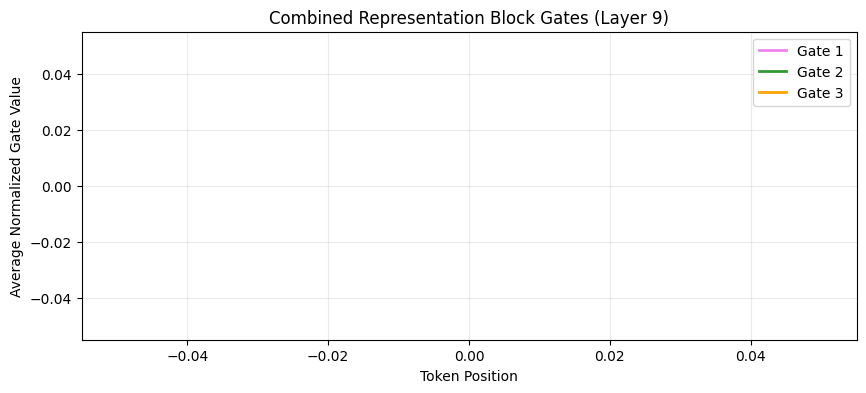

In [36]:
gate1 = model.transformer.h["9"].combined_representation_block.current_gates[0].squeeze(0)
gate2 = model.transformer.h["9"].combined_representation_block.current_gates[1].squeeze(0)
gate3 = model.transformer.h["9"].combined_representation_block.current_gates[2].squeeze(0)

gate1 = gate1 / (gate1 + gate2 + gate3)
gate2 = gate2 / (gate1 + gate2 + gate3)
gate3 = gate3 / (gate1 + gate2 + gate3)

gate1 = gate1.mean(dim=-1).detach().cpu().numpy()
gate2 = gate2.mean(dim=-1).detach().cpu().numpy()
gate3 = gate3.mean(dim=-1).detach().cpu().numpy()

# Set a darker pastel color scheme for the three gates
pastel_colors = ['violet', 'green', 'orange']  

plt.figure(figsize=(10, 4))
plt.plot(gate1, label='Gate 1', color=pastel_colors[0], linewidth=2)
plt.plot(gate2, label='Gate 2', color=pastel_colors[1], linewidth=2, alpha=0.8)
plt.plot(gate3, label='Gate 3', color=pastel_colors[2], linewidth=2)
plt.xlabel('Token Position')
plt.ylabel('Average Normalized Gate Value')
plt.title('Combined Representation Block Gates (Layer 9)')
plt.grid(alpha=0.25)
plt.legend()
# each 100 tokens, add a vertical line to indicate the token position

for pos in range(0, len(gate1), 10):
    plt.axvline(x=pos, color='gray', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [34]:
model.transformer.h["9"].combined_representation_block.current_gates_normalized[0].shape

torch.Size([1, 528, 1024])

In [41]:
gates_stack = torch.stack([model.transformer.h["9"].combined_representation_block.current_gates[i] for i in range(3)], dim=0)
print(gates_stack.shape)
gates_stack = gates_stack / (gates_stack.sum(dim=0) + 1e-8)

torch.Size([3, 1, 271, 1024])


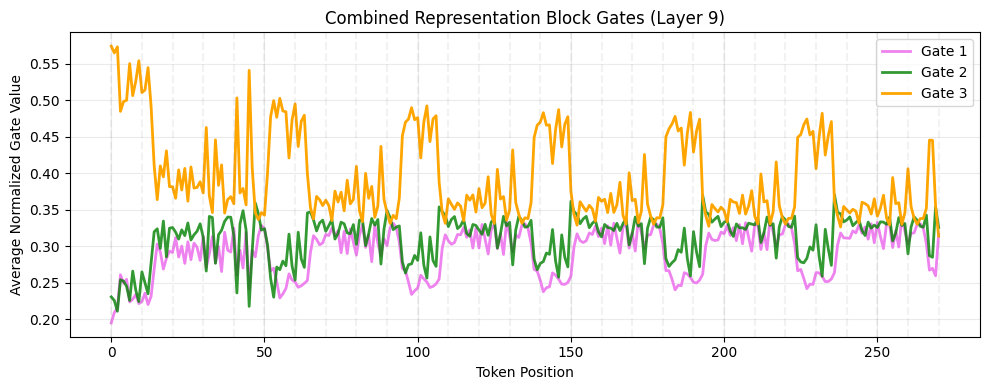

In [42]:
# gate1 = model.transformer.h["9"].combined_representation_block.current_gates_normalized[0].squeeze(0).mean(dim=-1).detach().cpu()
# gate2 = model.transformer.h["9"].combined_representation_block.current_gates_normalized[1].squeeze(0).mean(dim=-1).detach().cpu()
# gate3 = model.transformer.h["9"].combined_representation_block.current_gates_normalized[2].squeeze(0).mean(dim=-1).detach().cpu()
gate1 = gates_stack[0].squeeze(0).mean(dim=-1).detach().cpu().numpy()
gate2 = gates_stack[1].squeeze(0).mean(dim=-1).detach().cpu().numpy()
gate3 = gates_stack[2].squeeze(0).mean(dim=-1).detach().cpu().numpy()

# Set a darker pastel color scheme for the three gates
pastel_colors = ['violet', 'green', 'orange']  

plt.figure(figsize=(10, 4))
plt.plot(gate1, label='Gate 1', color=pastel_colors[0], linewidth=2)
plt.plot(gate2, label='Gate 2', color=pastel_colors[1], linewidth=2, alpha=0.8)
plt.plot(gate3, label='Gate 3', color=pastel_colors[2], linewidth=2)
plt.xlabel('Token Position')
plt.ylabel('Average Normalized Gate Value')
plt.title('Combined Representation Block Gates (Layer 9)')
plt.grid(alpha=0.25)
plt.legend()
# each 100 tokens, add a vertical line to indicate the token position

for pos in range(0, len(gate1), 10):
    plt.axvline(x=pos, color='gray', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

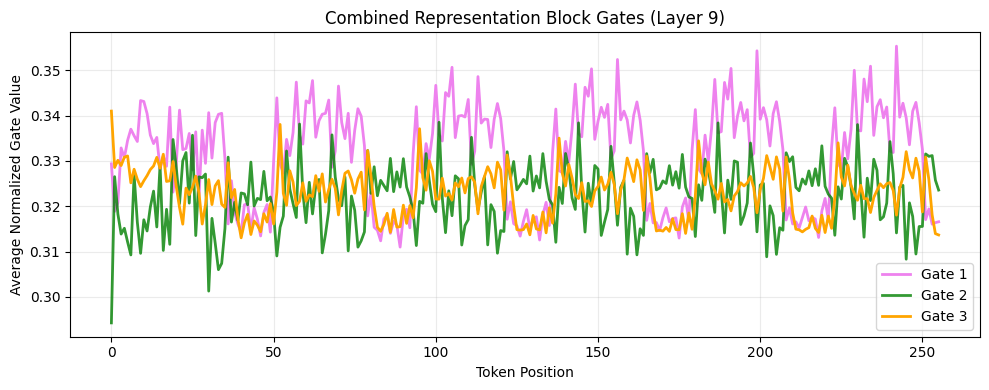

In [44]:
gate1 = np.asarray([output_gate_token_lookup[i]["gate1"] for i in range(len(output_gate_token_lookup))])
gate2 = np.asarray([output_gate_token_lookup[i]["gate2"] for i in range(len(output_gate_token_lookup))])
gate3 = np.asarray([output_gate_token_lookup[i]["gate3"] for i in range(len(output_gate_token_lookup))])

# Set a darker pastel color scheme for the three gates
pastel_colors = ['violet', 'green', 'orange']  

plt.figure(figsize=(10, 4))
plt.plot(gate1, label='Gate 1', color=pastel_colors[0], linewidth=2)
plt.plot(gate2, label='Gate 2', color=pastel_colors[1], linewidth=2, alpha=0.8)
plt.plot(gate3, label='Gate 3', color=pastel_colors[2], linewidth=2)
plt.xlabel('Token Position')
plt.ylabel('Average Normalized Gate Value')
plt.title('Combined Representation Block Gates (Layer 9)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

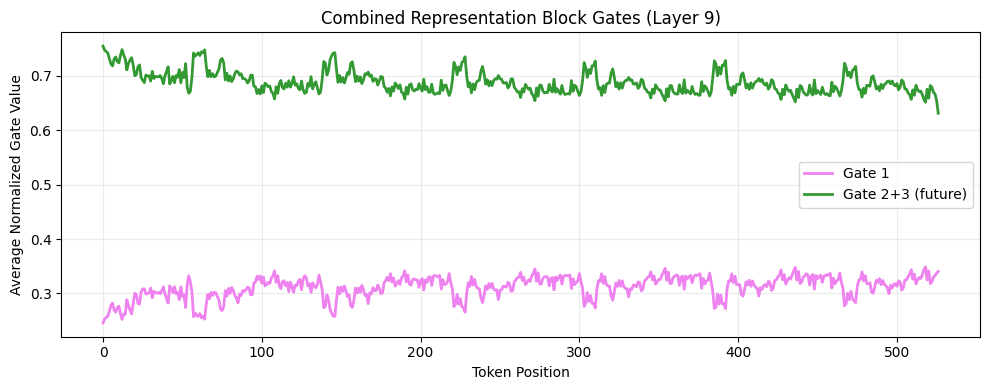

In [201]:
# Set a darker pastel color scheme for the three gates
pastel_colors = ['violet', 'green', 'orange']  

plt.figure(figsize=(10, 4))
plt.plot(gate1, label='Gate 1', color=pastel_colors[0], linewidth=2)
plt.plot(gate2+gate3, label='Gate 2+3 (future)', color=pastel_colors[1], linewidth=2, alpha=0.8)
plt.xlabel('Token Position')
plt.ylabel('Average Normalized Gate Value')
plt.title('Combined Representation Block Gates (Layer 9)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [163]:
# # Plot stacked bar chart of gate portions (sum to 1 at each token position)
# total = gate1 + gate2 + gate3
# portion1 = gate1 / total.clamp_min(1e-12)
# portion2 = gate2 / total.clamp_min(1e-12)
# portion3 = gate3 / total.clamp_min(1e-12)

# x = range(len(gate1))
# plt.figure(figsize=(10, 4))
# plt.bar(x, portion1, label='Gate 1 Portion', color=pastel_colors[0], width=1.0)
# plt.bar(x, portion2, bottom=portion1, label='Gate 2 Portion', color=pastel_colors[1], width=1.0)
# plt.bar(x, portion3, bottom=portion1 + portion2, label='Gate 3 Portion', color=pastel_colors[2], width=1.0)
# plt.ylim(0, 1.0)
# plt.xlabel('Token Position')
# plt.ylabel('Portion of Total Gate Value')
# plt.title('Stacked Gate Portions in Combined Representation Block (Layer 9)')
# plt.grid(alpha=0.25, axis='y')
# plt.legend()
# plt.tight_layout()
# plt.show()

In [9]:
torch.nn.functional.softplus(model.transformer.h["9"].combined_representation_block.gate_bias.mean(dim=1))

tensor([0.7274, 0.0254, 0.0582], device='cuda:0', grad_fn=<SoftplusBackward0>)

In [96]:
biases = model.transformer.h["9"].combined_representation_block.gate_bias.clone().detach()

In [97]:
model.transformer.h["9"].combined_representation_block.gate_bias.data = torch.zeros_like(model.transformer.h["9"].combined_representation_block.gate_bias)+ 100
model.transformer.h["9"].combined_representation_block.gate_bias.data[0] = biases[0]*100
model.transformer.h["9"].combined_representation_block.gate_bias

Parameter containing:
tensor([[ 3722.7795, -1402.8184,   781.0834,  ...,  -944.8605,  1049.5281,
          -330.2496],
        [  100.0000,   100.0000,   100.0000,  ...,   100.0000,   100.0000,
           100.0000],
        [  100.0000,   100.0000,   100.0000,  ...,   100.0000,   100.0000,
           100.0000]], device='cuda:0', requires_grad=True)

In [98]:
model.transformer.h["9"].max_recurrence=3

In [99]:
torch.nn.functional.softplus(model.transformer.h["9"].combined_representation_block.gate_bias).mean(dim=1)

tensor([2259.3867,  100.0000,  100.0000], device='cuda:0',
       grad_fn=<MeanBackward1>)

In [37]:
def get_logits(input_ids: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        output = model({'input_ids': input_ids})
        if isinstance(output, dict):
            logits_output = output.get('logits', output)
            if isinstance(logits_output, dict):
                return logits_output.get('logits', logits_output)
            return logits_output
        return output

print('Model loaded and ready.')
print('Tokenizer type:', type(tokenizer).__name__)

def generate_text(
    prompt: str,
    max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
    temperature: float = TEMPERATURE,
    stop_strings=None,
):
    if stop_strings is None:
        stop_strings = []

    input_tokens = tokenizer.tokenize(prompt)
    if len(input_tokens) > MAX_CONTEXT_TOKENS:
        input_tokens = input_tokens[-MAX_CONTEXT_TOKENS:]

    generated = []

    for _ in range(max_new_tokens):
        current = (input_tokens + generated)[-MAX_CONTEXT_TOKENS:]
        input_ids = torch.tensor([current], dtype=torch.long, device=DEVICE)

        logits = get_logits(input_ids)
        next_logits = logits[0, -1, :]

        if temperature and temperature > 0:
            probs = F.softmax(next_logits / temperature, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
        else:
            next_token = torch.argmax(next_logits).item()

        generated.append(next_token)
        text = tokenizer.decode(generated)

        if any(s and s in text for s in stop_strings):
            for s in stop_strings:
                if s and s in text:
                    text = text[:text.find(s)]
            return text

    return tokenizer.decode(generated)

def ask(prompt: str, **kwargs):
    completion = generate_text(prompt, **kwargs)
    # print('PROMPT:', prompt)
    # print('\nMODEL OUTPUT:\n', completion)
    return completion

Model loaded and ready.
Tokenizer type: PreTrainedHFTokenizer


In [38]:
# prompt = "Give me a python code which prints 'Hello, World!'"
prompt = 'What is 12 to the power of 2 divide by 6 and then plus 5?'

In [39]:
# for temp in [0.0, 0.1, 0.3, 0.4, 0.5]:
for temp in [0.0]:
    print(f'\n====== Temperature: {temp} =======')
    ask(
        # 'What is 12 to the power of 2 divide by 6 and then plus 5?',
        # 'Alex had 12 apples. He gave half of them to his friend. Then he bought 5 more apples. How many apples does Alex have now?',
        prompt,
        temperature=temp,
        max_new_tokens=256,
    )



====== Temperature: 0.0 =======


In [43]:
# Token <-> gate-position lookup for prompt AND generated output

layer_for_gates = "9"
max_new_tokens_for_gates = 256
temperature_for_gates = 0.0

hf_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

def ids_to_tokens(ids):
    if hasattr(hf_tokenizer, "convert_ids_to_tokens"):
        return hf_tokenizer.convert_ids_to_tokens(ids)
    return [tokenizer.decode([tid]) for tid in ids]

def get_layer_gates(input_token_ids, layer_key):
    input_ids = torch.tensor([input_token_ids], dtype=torch.long, device=DEVICE)
    with torch.no_grad():
        logits = get_logits(input_ids)
    block = model.transformer.h[layer_key].combined_representation_block
    g1 = block.current_gates_normalized[0].squeeze(0).mean(dim=-1).detach().cpu()
    g2 = block.current_gates_normalized[1].squeeze(0).mean(dim=-1).detach().cpu()
    g3 = block.current_gates_normalized[2].squeeze(0).mean(dim=-1).detach().cpu()
    return logits, g1, g2, g3

# ----- Prompt mapping -----
prompt_token_ids = tokenizer.tokenize(prompt)
_, pg1, pg2, pg3 = get_layer_gates(prompt_token_ids, layer_for_gates)
prompt_tokens = ids_to_tokens(prompt_token_ids)

prompt_gate_token_lookup = [
    {
        "pos": i,
        "token_id": int(prompt_token_ids[i]),
        "token": prompt_tokens[i],
        "gate1": float(pg1[i]),
        "gate2": float(pg2[i]),
        "gate3": float(pg3[i]),
    }
    for i in range(len(prompt_token_ids))
]

# ----- Output mapping (generated tokens) -----
generated_ids = []
output_gate_token_lookup = []
tokens_gates_through_time = {
    t: {"gate1": [], "gate2": [], "gate3": []} for t in range(max_new_tokens_for_gates)
}

for out_pos in tqdm(range(max_new_tokens_for_gates)):
    # Predict next token from current sequence
    current_ids = (prompt_token_ids + generated_ids)[-MAX_CONTEXT_TOKENS:]
    logits, _, _, _ = get_layer_gates(current_ids, layer_for_gates)
    next_logits = logits[0, -1, :]

    if temperature_for_gates and temperature_for_gates > 0:
        probs = F.softmax(next_logits / temperature_for_gates, dim=-1)
        next_token_id = int(torch.multinomial(probs, num_samples=1).item())
    else:
        next_token_id = int(torch.argmax(next_logits).item())

    generated_ids.append(next_token_id)

    # Re-run with the new token included so we can read gate values for that output token position
    full_ids = (prompt_token_ids + generated_ids)[-MAX_CONTEXT_TOKENS:]
    _, fg1, fg2, fg3 = get_layer_gates(full_ids, layer_for_gates)
    last_pos = len(full_ids) - 1
    tok = ids_to_tokens([next_token_id])[0]
    
    output_gate_token_lookup.append(
        {
            "out_pos": out_pos,
            "full_pos": last_pos,
            "token_id": next_token_id,
            "token": tok,
            "gate1": float(fg1[last_pos]),
            "gate2": float(fg2[last_pos]),
            "gate3": float(fg3[last_pos]),
        }
    )
    
    full_len = len(full_ids)
    gen_in_full = min(len(generated_ids), full_len)
    gen_start = len(prompt_token_ids)

    for k in range(gen_in_full):
        tokens_gates_through_time[k]["gate1"].append(float(fg1[gen_start + k]))
        tokens_gates_through_time[k]["gate2"].append(float(fg2[gen_start + k]))
        tokens_gates_through_time[k]["gate3"].append(float(fg3[gen_start + k]))

# Convenience maps
prompt_position_to_token = {row["pos"]: row["token"] for row in prompt_gate_token_lookup}
output_position_to_token = {row["out_pos"]: row["token"] for row in output_gate_token_lookup}

print(f"Prompt token count: {len(prompt_gate_token_lookup)}")
print(f"Generated token count: {len(output_gate_token_lookup)}")
print("\nPrompt mapping (first 40):")
for row in prompt_gate_token_lookup[:40]:
    print(
        f"P {row['pos']:>3} | id={row['token_id']:>6} | tok={repr(row['token'])} "
        f"| g1={row['gate1']:.4f} g2={row['gate2']:.4f} g3={row['gate3']:.4f}"
    )

print("\nOutput mapping (all generated tokens):")
for row in output_gate_token_lookup:
    print(
        f"O {row['out_pos']:>3} | id={row['token_id']:>6} | tok={repr(row['token'])} "
        f"| g1={row['gate1']:.4f} g2={row['gate2']:.4f} g3={row['gate3']:.4f}"
    )

# print("\nGenerated text:")
print(tokenizer.decode(generated_ids))

  0%|          | 0/256 [00:00<?, ?it/s]

100%|██████████| 256/256 [00:19<00:00, 13.21it/s]

Prompt token count: 16
Generated token count: 256

Prompt mapping (first 40):
P   0 | id=  2061 | tok='What' | g1=0.1950 g2=0.2306 g3=0.5744
P   1 | id=   318 | tok='Ġis' | g1=0.2092 g2=0.2256 g3=0.5652
P   2 | id=  1105 | tok='Ġ12' | g1=0.2156 g2=0.2109 g3=0.5735
P   3 | id=   284 | tok='Ġto' | g1=0.2609 g2=0.2541 g3=0.4850
P   4 | id=   262 | tok='Ġthe' | g1=0.2494 g2=0.2522 g3=0.4984
P   5 | id=  1176 | tok='Ġpower' | g1=0.2547 g2=0.2451 g3=0.5002
P   6 | id=   286 | tok='Ġof' | g1=0.2237 g2=0.2258 g3=0.5505
P   7 | id=   362 | tok='Ġ2' | g1=0.2274 g2=0.2660 g3=0.5066
P   8 | id= 14083 | tok='Ġdivide' | g1=0.2339 g2=0.2398 g3=0.5263
P   9 | id=   416 | tok='Ġby' | g1=0.2214 g2=0.2241 g3=0.5544
P  10 | id=   718 | tok='Ġ6' | g1=0.2242 g2=0.2649 g3=0.5108
P  11 | id=   290 | tok='Ġand' | g1=0.2357 g2=0.2500 g3=0.5143
P  12 | id=   788 | tok='Ġthen' | g1=0.2201 g2=0.2349 g3=0.5450
P  13 | id=  5556 | tok='Ġplus' | g1=0.2314 g2=0.2768 g3=0.4918
P  14 | id=   642 | tok='Ġ5' | g1=0.2693 g

In [26]:
tokens_gates_through_time[2]["gate3"][0]

0.3051666021347046

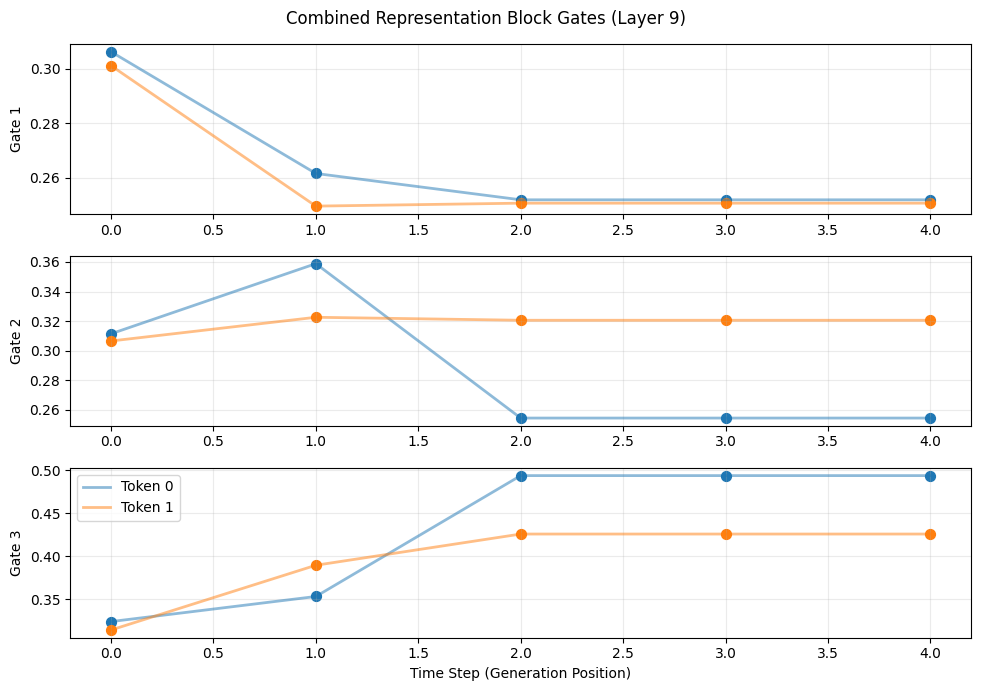

In [27]:
fig, ax = plt.subplots(3, 1, figsize=(10, 7))
beg = 0
for tok in range(beg,beg+2):
    ax[0].plot(tokens_gates_through_time[tok]["gate1"][:5], label=f'Token {tok}', linewidth=2, alpha=.5)
    ax[0].scatter(range(len(tokens_gates_through_time[tok]["gate1"][:5])), tokens_gates_through_time[tok]["gate1"][:5], s=50)
    ax[1].plot(tokens_gates_through_time[tok]["gate2"][:5], label=f'Token {tok}', linewidth=2, alpha=.5)
    ax[1].scatter(range(len(tokens_gates_through_time[tok]["gate2"][:5])), tokens_gates_through_time[tok]["gate2"][:5], s=50)
    ax[2].plot(tokens_gates_through_time[tok]["gate3"][:5], label=f'Token {tok}', linewidth=2, alpha=.5)
    ax[2].scatter(range(len(tokens_gates_through_time[tok]["gate3"][:5])), tokens_gates_through_time[tok]["gate3"][:5], s=50)


ax[2].set_xlabel('Time Step (Generation Position)')

ax[0].set_ylabel('Gate 1')
ax[1].set_ylabel('Gate 2')
ax[2].set_ylabel('Gate 3')
fig.suptitle('Combined Representation Block Gates (Layer 9)')
ax[0].grid(alpha=0.25)
ax[1].grid(alpha=0.25)
ax[2].grid(alpha=0.25)


plt.legend()
# each 100 tokens, add a vertical line to indicate the token position

# for pos in range(0, len(gate1), 10):
#     plt.axvline(x=pos, color='gray', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

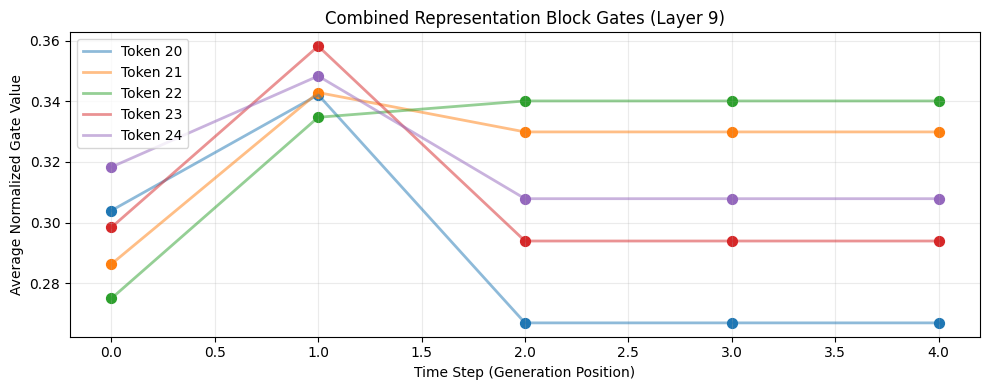

In [280]:
plt.figure(figsize=(10, 4))
beg = 20
for tok in range(beg,beg+5):
    plt.plot(tokens_gates_through_time[tok]["gate2"][:5], label=f'Token {tok}', linewidth=2, alpha=.5)
    plt.scatter(range(len(tokens_gates_through_time[tok]["gate2"][:5])), tokens_gates_through_time[tok]["gate2"][:5], s=50)
    # plt.plot(tokens_gates_through_time[tok]["gate2"], label='Gate 2', linewidth=2, alpha=0.5)
    # plt.plot(tokens_gates_through_time[tok]["gate3"], label='Gate 3', linewidth=2, alpha=0.5)
plt.xlabel('Time Step (Generation Position)')
plt.ylabel('Average Normalized Gate Value')
plt.title('Combined Representation Block Gates (Layer 9)')
plt.grid(alpha=0.25)
plt.legend()
# each 100 tokens, add a vertical line to indicate the token position

# for pos in range(0, len(gate1), 10):
#     plt.axvline(x=pos, color='gray', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

In [ ]:
# TODO: look at latent thought and see if we can get any insights

In [260]:
len(tokens_gates_through_time[tok]["gate1"])

508

In [257]:
(tokens_gates_through_time[0]["gate1"])

[0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.24604111909866333,
 0.2460411